<a href="https://colab.research.google.com/github/AleksiOikarinen/Schoolwork-New/blob/main/Data_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("/content/Movie_Data_File.csv")

df = df.drop(columns=["Release_year"]) #Tuotanto vuodet olivat NaN joten ne pitää poistaa // Tämä koodi pitää myös olla ennen kuin datasetti tulostetaan
df = df.drop(columns=["Owner_rating"]) #Owner rating vähän turha
sampled_df = df.sample(n=200, random_state=42) # Samplee elokuva määrän 200 kun 10000 on aika hankala lukea visuaalisoinnissa
print('Rivien ja sarakkeiden määrä:', df.shape)

Rivien ja sarakkeiden määrä: (10002, 27)


In [17]:
print(df.isna().sum())#tulostetaan puuttuvien tietojen määrä
df = df.drop_duplicates()
df.sample(5)#tulostetaan 5 random riviä


Film_title             0
Director              10
Cast                  57
Average_rating       581
Genres                24
Runtime               10
Countries            118
Original_language      3
Spoken_languages       3
Description            2
Studios              307
Watches                0
List_appearances       0
Likes                  0
Fans                   0
½                      0
★                      0
★½                     0
★★                     0
★★½                    0
★★★                    0
★★★½                   0
★★★★                   0
★★★★½                  0
★★★★★                  0
Total_ratings          0
Film_URL               0
dtype: int64


,Film_title,Director,Cast,Average_rating,Genres,Runtime,Countries,Original_language,Spoken_languages,Description,...,★½,★★,★★½,★★★,★★★½,★★★★,★★★★½,★★★★★,Total_ratings,Film_URL
5295,Man on a Tightrope,Elia Kazan,"['Fredric March', 'Terry Moore', 'Gloria Graha...",3.47,"['Drama', 'Thriller']",105.0,"['Germany', 'USA']",English,['English'],The owner of an impoverished circus in Communi...,...,16,45,62,220,249,218,37,30,885,https://letterboxd.com/film/man-on-a-tightrope/
2611,Performance,"Nicolas Roeg, Donald Cammell","['James Fox', 'Mick Jagger', 'Anita Pallenberg...",3.58,"['Drama', 'Crime']",106.0,['UK'],English,['English'],"In underworld terms, Chas Devlin is a 'perform...",...,286,939,1232,3118,3561,4255,1463,1536,16731,https://letterboxd.com/film/performance/
3323,Self/less,Tarsem Singh,"['Ryan Reynolds', 'Ben Kingsley', 'Natalie Mar...",2.76,"['Science Fiction', 'Thriller', 'Action']",117.0,['USA'],English,['English'],An extremely wealthy elderly man dying from ca...,...,1695,5372,6165,9202,4621,2693,444,732,32445,https://letterboxd.com/film/self-less/
3108,The Las Vegas Story,Robert Stevenson,"['Jane Russell', 'Victor Mature', 'Vincent Pri...",3.20,"['Drama', 'Thriller', 'Crime']",88.0,['USA'],English,['English'],"When newlyweds visit Las Vegas, the wife's sha...",...,16,80,166,436,264,117,17,18,1125,https://letterboxd.com/film/the-las-vegas-story/
5174,Nitro Circus: The Movie,"Jeremy Rawle, Gregg Godfrey","['Travis Pastrana', 'Jolene Van Vugt', 'Tommy ...",3.15,"['Comedy', 'Action', 'Documentary']",92.0,['USA'],English,['English'],You will see Travis Pastrana and the whole Nit...,...,66,195,286,753,386,278,51,87,2154,https://letterboxd.com/film/nitro-circus-the-m...


<Figure size 1000x600 with 0 Axes>

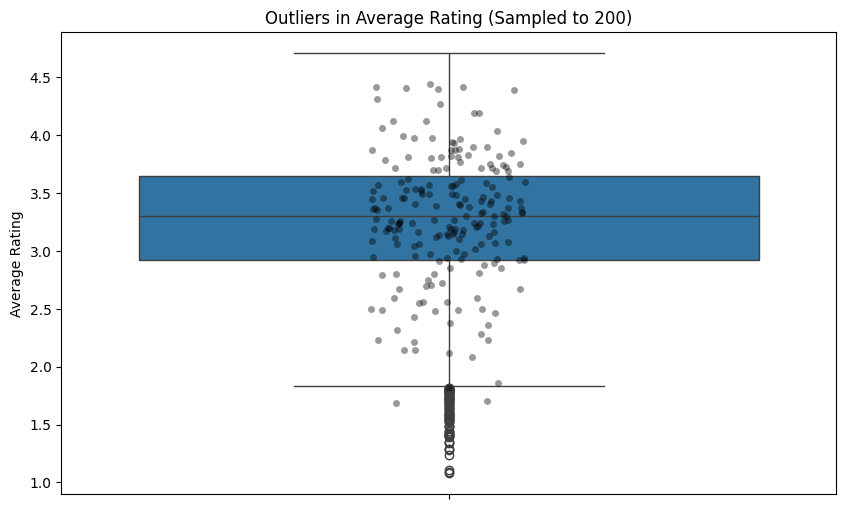

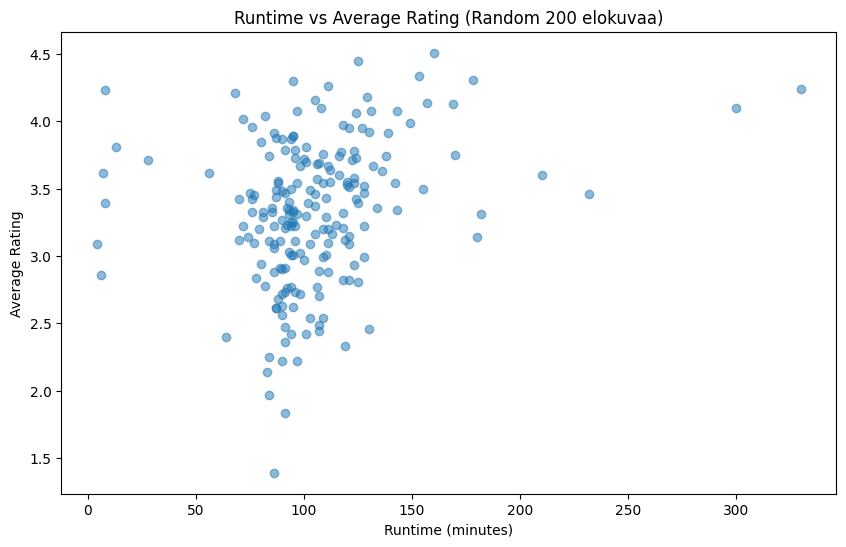

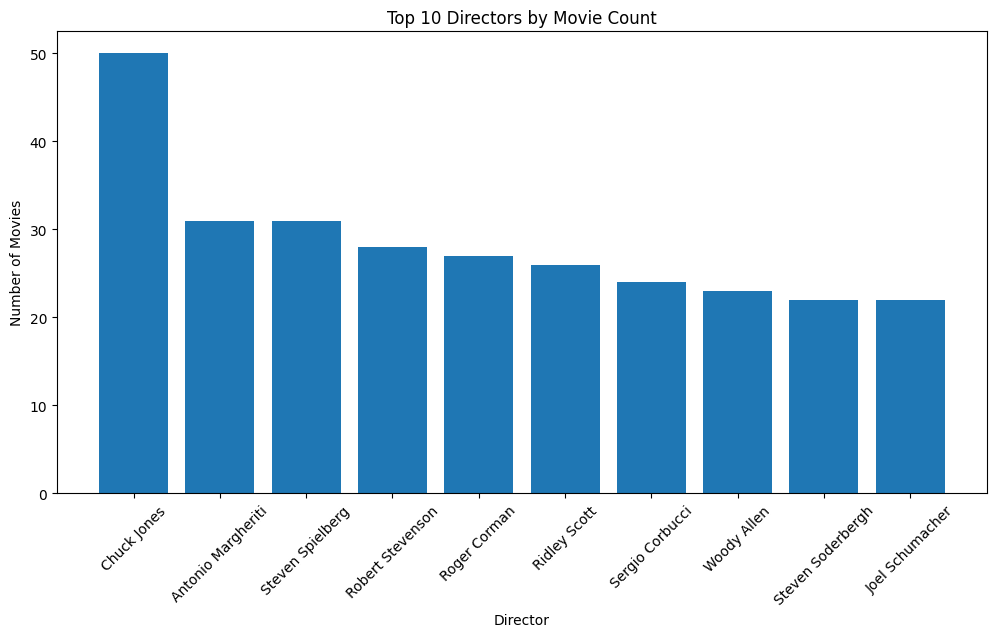

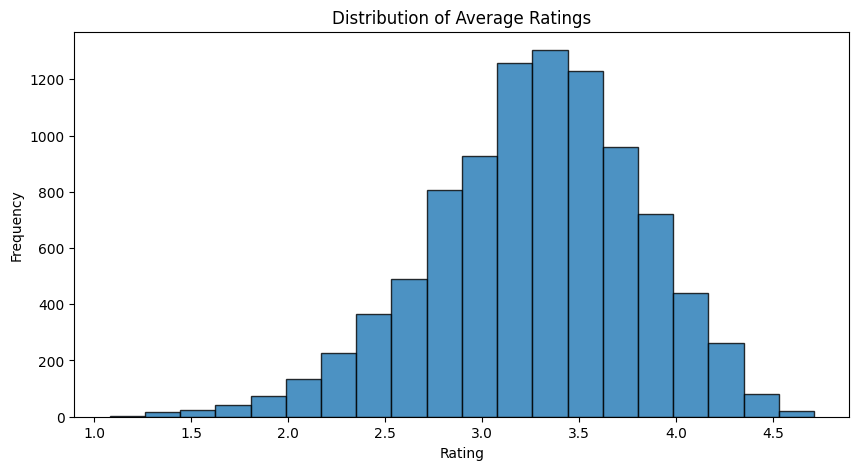

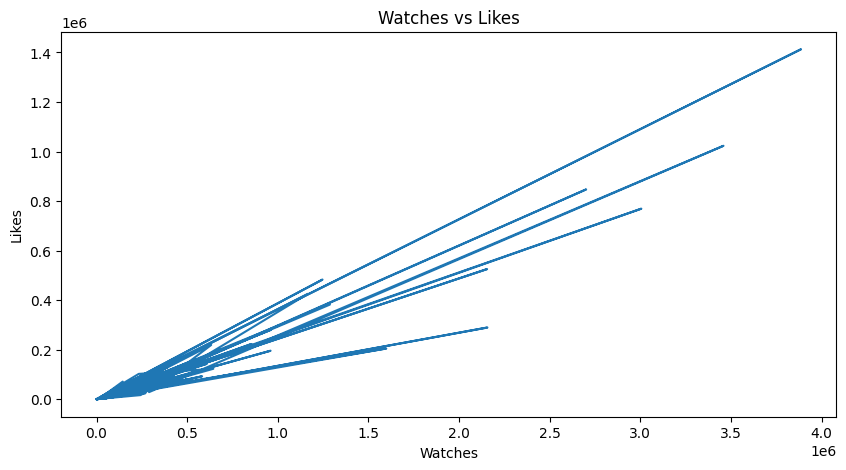

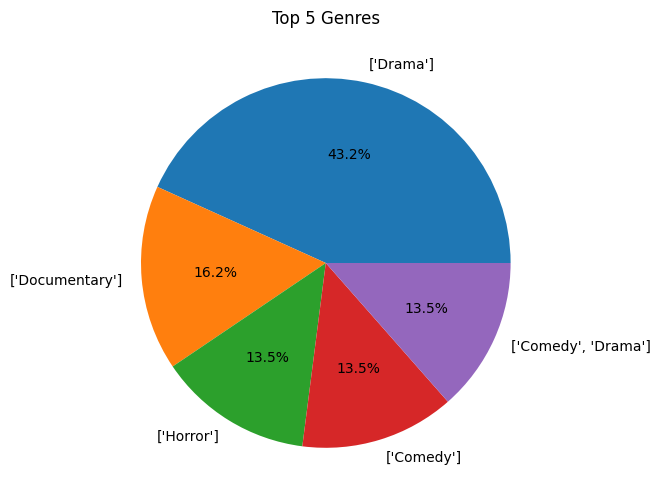

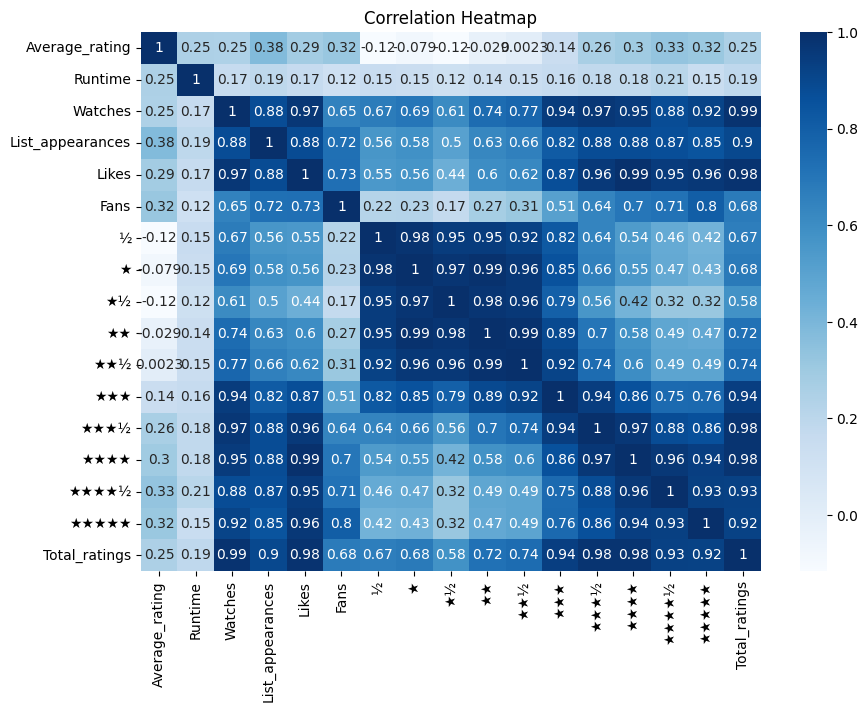

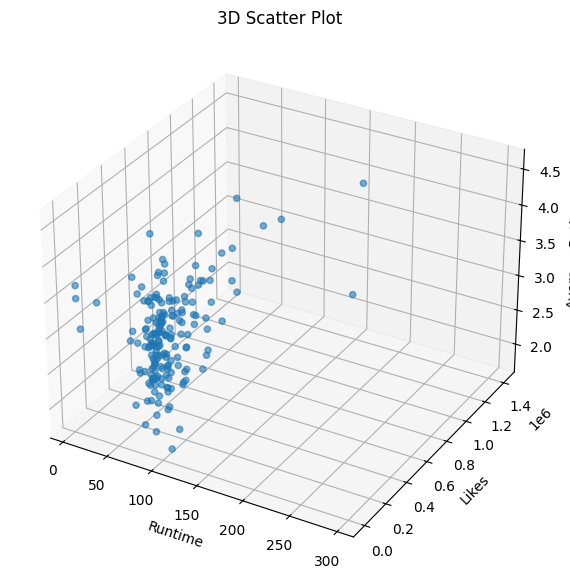

In [18]:

df['Director'] = df['Director'].fillna("Unknown")
df = df.dropna(subset=['Average_rating'])

df["Rating_bin"] = pd.qcut(
    df["Average_rating"],
    q=4,
    labels=["Low", "Below Average", "Above Average", "High"]
)


plt.figure(figsize=(10, 6))

sample = df['Average_rating'].sample(200)

#OG

plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Average_rating'])
sns.stripplot(y=sample, color="black", alpha=0.4)
plt.title("Outliers in Average Rating (Sampled to 200)")
plt.ylabel("Average Rating")
plt.show()


#Scatter plot
sample = df.sample(200)

plt.figure(figsize=(10, 6))
plt.scatter(sample["Runtime"], sample["Average_rating"], alpha=0.5)

plt.title("Runtime vs Average Rating (Random 200 elokuvaa)")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Average Rating")
plt.show()


#Bar chart
plt.figure(figsize=(12,6))
top_directors = df['Director'].value_counts().head(10)

plt.bar(top_directors.index, top_directors.values)
plt.title("Top 10 Directors by Movie Count")
plt.xlabel("Director")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.show()


#Histogram
plt.figure(figsize=(10,5))
plt.hist(df["Average_rating"], bins=20, edgecolor="black",linewidth=1,alpha=0.8)

plt.title("Distribution of Average Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

#Line plot
plt.figure(figsize=(10,5))
plt.plot(sampled_df["Watches"], sampled_df["Likes"])
plt.title("Watches vs Likes")
plt.xlabel("Watches")
plt.ylabel("Likes")
plt.show()

#Pie chart
genre_counts = sampled_df["Genres"].value_counts().head(5)

plt.figure(figsize=(6,6))
plt.pie(genre_counts, labels=genre_counts.index, autopct="%1.1f%%")
plt.title("Top 5 Genres")
plt.show()

#Heatmap
numeric_df = sampled_df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

#3D plot

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(sampled_df["Runtime"], sampled_df["Likes"], sampled_df["Average_rating"], alpha=0.6)

ax.set_xlabel("Runtime")
ax.set_ylabel("Likes")
ax.set_zlabel("Average Rating")
plt.title("3D Scatter Plot")
plt.show()


In [19]:
#Binnaus

print("\nHead with Rating_bin:")
print(df[["Average_rating", "Rating_bin"]].head())

print("\nValue counts for bins:")
print(df["Rating_bin"].value_counts())



Head with Rating_bin:
   Average_rating     Rating_bin
0            3.57  Above Average
1            4.18           High
2            3.93           High
3            3.79           High
4            4.28           High

Value counts for bins:
Rating_bin
Below Average    2389
Low              2349
High             2339
Above Average    2315
Name: count, dtype: int64


In [20]:
#Attribute types

ordinal_columns = ["Rating_bin"]
types = {
    "Nominaali": [],
    "Ordinaali": [],
    "Binaari": []
}
for col in df.columns:
  unique_vals = df[col].dropna().unique()
  n_unique = len(unique_vals)
  dtype = df[col].dtype

  if col in ordinal_columns:
    types["Ordinaali"].append(col)

  elif n_unique == 2:
    types["Binaari"].append(col)

  elif dtype == "object":
    types["Nominaali"].append(col)

print("Nominaalit:", types["Nominaali"])
print("Ordinaalit:", types["Ordinaali"])
print("Binaarit:", types["Binaari"])

Nominaalit: ['Film_title', 'Director', 'Cast', 'Genres', 'Countries', 'Original_language', 'Spoken_languages', 'Description', 'Studios', 'Film_URL']
Ordinaalit: ['Rating_bin']
Binaarit: []


In [21]:
#Max rating
Highest_rating = np.max(df['Average_rating'])
print('Highest rating:', Highest_rating)

#Min rating
Lowest_rating = np.min(df['Average_rating'])
print('Lowest rating:', Lowest_rating)

#Calculate the mean and median values for appropriate columns
mean_rating = np.mean(df['Average_rating'])
print('The mean rating of Average_rating:', mean_rating)

median_rating = np.median(df['Average_rating'])
print('The median rating of Average_rating:', median_rating)

#accurately computes the standard deviation and variance of data
std_dev_rating = np.std(df['Average_rating'], ddof = 1)
print("The sample standard deviation of Average_rating:", std_dev_rating)

variance_rating = np.var(df['Average_rating'])
print("The variance of Average_rating:", variance_rating)

#accurately calculates the sum and product of data
sum_watches = np.sum(df['Watches'])
print("Total amount of watches across all of the movies:", sum_watches)


Highest rating: 4.71
Lowest rating: 1.08
The mean rating of Average_rating: 3.2691620528109024
The median rating of Average_rating: 3.3
The sample standard deviation of Average_rating: 0.5418558510543807
The variance of Average_rating: 0.29357650184791895
Total amount of watches across all of the movies: 1700211170
